## F: Load ANSYS Magnetic Field Data

Load magnetic field data exported from ANSYS.

---

**Input**
- `filename` *(str)* – Path to the ANSYS B-field export text file.

**Function**
- `x, y, z, Bx, By, Bz, Bmag = load_ansys_bfield("bfield_export.txt")`

In [21]:

import numpy as np
import matplotlib.pyplot as plt


# =========================
# 0) Load ANSYS B-field export
# =========================
def load_ansys_bfield(filename):
    """
    Reads magnetic field data exported from ANSYS and extracts
    the spatial coordinates and magnetic field components.

    Expected file columns:
    X  Y  Z  Bx_re  Bx_im  By_re  By_im  Bz_re  Bz_im
    """

    # List to store valid numeric rows from the file
    rows = []

    # Open the file for reading
    with open(filename, "r") as f:

        # Read the file line by line
        for line in f:

            # Remove leading/trailing spaces and newline characters
            line = line.strip()

            # Skip empty lines
            if not line:
                continue

            # Split the line into individual columns
            parts = line.split()

            # Check if the first column is numeric
            # If not, this is likely a header or text line -> skip it
            try:
                float(parts[0])
            except (ValueError, IndexError):
                continue

            # Convert all values in the row to floats
            # If conversion fails, skip the row
            try:
                vals = [float(v) for v in parts]
                rows.append(vals)
            except ValueError:
                continue

    # Convert the list of rows into a NumPy array
    data = np.array(rows, dtype=float)

    # Verify the file contains at least the expected 9 columns
    if data.ndim != 2 or data.shape[1] < 9:
        raise ValueError(
            f"Expected at least 9 columns, got shape {data.shape}. "
            "Expected: X Y Z Bx_re Bx_im By_re By_im Bz_re Bz_im"
        )

    # Extract spatial coordinates
    x = data[:, 0]   # X position
    y = data[:, 1]   # Y position
    z = data[:, 2]   # Z position

    # Extract magnetic field real components
    # (Imaginary parts are ignored here)
    Bx = data[:, 3]  # Bx real component
    By = data[:, 5]  # By real component
    Bz = data[:, 7]  # Bz real component

    # Compute the magnetic field magnitude
    # |B| = sqrt(Bx^2 + By^2 + Bz^2)
    Bmag = np.sqrt(Bx**2 + By**2 + Bz**2)

    # Return coordinates and field components
    return x, y, z, Bx, By, Bz, Bmag

## F: Plot Slice Contours

These helper functions generate **2D contour plots of a field on an X–Z slice at a given Y plane**.

---

**Functions**

- `plot_slice_contour(x, y, z, F, y_value=None, tol=None, ...)`  
  Used for **scattered (unstructured) data**. It selects points close to the specified `Y` value and creates a triangulated contour plot.

- `plot_grid_slice_contour(xs, ys, zs, F, y_value=None, ...)`  
  Used for **structured grid data** where the field is stored as `F[x_index, y_index, z_index]`. It extracts the nearest Y slice and plots it.

**Input**
- `x, y, z` or `xs, ys, zs` – Spatial coordinates  
- `F` – Field values (e.g., `Bx`, `By`, `Bz`, or `Bmag`)  
- `y_value` *(optional)* – Y position of the slice (default: middle plane)

**Output**
- Displays a **2D contour plot of the field in the X–Z plane**.

In [22]:

# =========================
# 1) Plot helpers
# =========================
def plot_slice_contour(x, y, z, F, y_value=None, tol=None, title=None, cmap="jet"):
    unique_y = np.unique(y)

    if y_value is None:
        y_value = unique_y[len(unique_y) // 2]

    if tol is None:
        if len(unique_y) > 1:
            tol = 0.5 * np.min(np.diff(np.sort(unique_y)))
        else:
            tol = 1e-12

    mask = np.isclose(y, y_value, atol=tol)

    if np.sum(mask) < 3:
        raise ValueError(f"Not enough points found for y={y_value} with tol={tol}")

    plt.figure(figsize=(7, 5))
    plt.tricontourf(x[mask], z[mask], F[mask], levels=100, cmap=cmap)
    plt.xlabel("X")
    plt.ylabel("Z")
    plt.title(title if title is not None else f"Field contour at Y = {y_value}")
    plt.colorbar(label="Field")
    plt.tight_layout()
    plt.show()


def plot_grid_slice_contour(xs, ys, zs, F, ax=None, y_value=None, title=None, cmap="jet"):
    if ax is None:
        ax = plt.gca()

    if y_value is None:
        j = len(ys) // 2
    else:
        j = np.argmin(np.abs(ys - y_value))

    X2, Z2 = np.meshgrid(xs, zs, indexing="ij")
    slice2d = F[:, j, :]

    c = ax.contourf(X2, Z2, slice2d, levels=100, cmap=cmap)
    ax.set_xlabel("X")
    ax.set_ylabel("Z")
    ax.set_title(title if title is not None else f"Field contour at Y = {ys[j]}")

    return c

## F: Reshape Data to 3D Grid

---

Convert **scattered field data** into a **regular 3D grid**.

The function identifies the unique `x`, `y`, and `z` coordinates and reshapes the field components into structured arrays suitable for grid-based analysis or visualization.

**Input**
- `x, y, z` – Coordinate arrays (scattered points)
- `fx, fy, fz` – Field components at each point

**Function**
- `xs, ys, zs, FX, FY, FZ = reshape_to_grid(x, y, z, Bx, By, Bz)`

In [23]:

# =========================================================
# 2) Reshape scattered data to regular 3D grid
# =========================================================
def reshape_to_grid(x, y, z, fx, fy, fz):
    xs = np.unique(x)
    ys = np.unique(y)
    zs = np.unique(z)

    nx, ny, nz = len(xs), len(ys), len(zs)

    FX = np.full((nx, ny, nz), np.nan, dtype=float)
    FY = np.full((nx, ny, nz), np.nan, dtype=float)
    FZ = np.full((nx, ny, nz), np.nan, dtype=float)

    ix = {v: i for i, v in enumerate(xs)}
    iy = {v: i for i, v in enumerate(ys)}
    iz = {v: i for i, v in enumerate(zs)}

    for xx, yy, zz, a, b, c in zip(x, y, z, fx, fy, fz):
        i, j, k = ix[xx], iy[yy], iz[zz]
        FX[i, j, k] = a
        FY[i, j, k] = b
        FZ[i, j, k] = c

    if np.isnan(FX).any() or np.isnan(FY).any() or np.isnan(FZ).any():
        raise ValueError("Incomplete regular grid detected.")

    return xs, ys, zs, FX, FY, FZ

## F: Divergence Diagnostics

This section provides tools for **analyzing and correcting vector fields on a 3D grid**.

---

**Functions**

- `compute_divergence_fd(xs, ys, zs, Fx, Fy, Fz)`  
  Computes the **numerical divergence** of a vector field using finite-difference gradients.

- `pad_field(Fx, Fy, Fz, pad, mode)`  
  Adds padding to 3D field arrays to reduce boundary artifacts during spectral operations.

- `crop_field(F, pad)`  
  Removes previously added padding and restores the original grid size.

- `make_k_grids(nx, ny, nz, dx, dy, dz)`  
  Generates **Fourier-space wavevector grids** used for FFT-based calculations.

- `project_B_to_div_free_fft(Bx, By, Bz, dx, dy, dz)`  
  Uses a **spectral projection method** to enforce a divergence-free field by removing the compressive component in Fourier space.


In [24]:

# =========================================================
# 3) Finite-difference divergence diagnostic
# =========================================================
def compute_divergence_fd(xs, ys, zs, Fx, Fy, Fz):
    dFx_dx = np.gradient(Fx, xs, axis=0, edge_order=2)
    dFy_dy = np.gradient(Fy, ys, axis=1, edge_order=2)
    dFz_dz = np.gradient(Fz, zs, axis=2, edge_order=2)
    return dFx_dx + dFy_dy + dFz_dz


# =========================================================
# 4) Padding helpers
# =========================================================
def pad_field(Fx, Fy, Fz, pad=((16, 16), (16, 16), (16, 16)), mode="edge"):
    Fx_pad = np.pad(Fx, pad, mode=mode)
    Fy_pad = np.pad(Fy, pad, mode=mode)
    Fz_pad = np.pad(Fz, pad, mode=mode)
    return Fx_pad, Fy_pad, Fz_pad


def crop_field(F, pad):
    (px0, px1), (py0, py1), (pz0, pz1) = pad
    return F[px0:F.shape[0]-px1, py0:F.shape[1]-py1, pz0:F.shape[2]-pz1]


# =========================================================
# 5) Spectral utilities
# =========================================================
def make_k_grids(nx, ny, nz, dx, dy, dz):
    kx = 2.0 * np.pi * np.fft.fftfreq(nx, d=dx)
    ky = 2.0 * np.pi * np.fft.fftfreq(ny, d=dy)
    kz = 2.0 * np.pi * np.fft.fftfreq(nz, d=dz)
    return np.meshgrid(kx, ky, kz, indexing="ij")


def project_B_to_div_free_fft(Bx, By, Bz, dx, dy, dz):
    nx, ny, nz = Bx.shape
    KX, KY, KZ = make_k_grids(nx, ny, nz, dx, dy, dz)
    K2 = KX**2 + KY**2 + KZ**2
    K2[0, 0, 0] = 1.0

    Bx_hat = np.fft.fftn(Bx)
    By_hat = np.fft.fftn(By)
    Bz_hat = np.fft.fftn(Bz)

    k_dot_B = KX * Bx_hat + KY * By_hat + KZ * Bz_hat

    Bx_hat_p = Bx_hat - KX * k_dot_B / K2
    By_hat_p = By_hat - KY * k_dot_B / K2
    Bz_hat_p = Bz_hat - KZ * k_dot_B / K2

    Bx_hat_p[0, 0, 0] = Bx_hat[0, 0, 0]
    By_hat_p[0, 0, 0] = By_hat[0, 0, 0]
    Bz_hat_p[0, 0, 0] = Bz_hat[0, 0, 0]

    Bx_p = np.real(np.fft.ifftn(Bx_hat_p))
    By_p = np.real(np.fft.ifftn(By_hat_p))
    Bz_p = np.real(np.fft.ifftn(Bz_hat_p))

    return Bx_p, By_p, Bz_p

## F: FFT Vector Potential & Curl

These functions compute the **vector potential** from a magnetic field and reconstruct the magnetic field back from the vector potential using **FFT-based spectral methods**.

- `solve_A_from_B_fft(Bx, By, Bz, dx, dy, dz)`  
  Solves for the vector potential components `Ax`, `Ay`, and `Az` from the magnetic field components `Bx`, `By`, and `Bz` in Fourier space.

- `curl_of_A_fft(Ax, Ay, Az, dx, dy, dz)`  
  Computes the magnetic field as the **curl of the vector potential** and also returns the field magnitude.

**Input**
- `Bx, By, Bz` or `Ax, Ay, Az` – 3D field components  
- `dx, dy, dz` – Grid spacing

**Output**
- `Ax, Ay, Az` – Vector potential components  
- `Bx, By, Bz` – Reconstructed magnetic field components  
- `Bmag` – Magnetic field magnitude

These utilities are useful for spectral field reconstruction based on:

\[
\mathbf{B} = \nabla \times \mathbf{A}
\]

In [25]:

def solve_A_from_B_fft(Bx, By, Bz, dx, dy, dz):
    nx, ny, nz = Bx.shape
    KX, KY, KZ = make_k_grids(nx, ny, nz, dx, dy, dz)
    K2 = KX**2 + KY**2 + KZ**2
    K2[0, 0, 0] = 1.0

    Bx_hat = np.fft.fftn(Bx)
    By_hat = np.fft.fftn(By)
    Bz_hat = np.fft.fftn(Bz)

    Ax_hat = -1j * (KY * Bz_hat - KZ * By_hat) / K2
    Ay_hat = -1j * (KZ * Bx_hat - KX * Bz_hat) / K2
    Az_hat = -1j * (KX * By_hat - KY * Bx_hat) / K2

    Ax_hat[0, 0, 0] = 0.0
    Ay_hat[0, 0, 0] = 0.0
    Az_hat[0, 0, 0] = 0.0

    Ax = np.real(np.fft.ifftn(Ax_hat))
    Ay = np.real(np.fft.ifftn(Ay_hat))
    Az = np.real(np.fft.ifftn(Az_hat))
    return Ax, Ay, Az


def curl_of_A_fft(Ax, Ay, Az, dx, dy, dz):
    nx, ny, nz = Ax.shape
    KX, KY, KZ = make_k_grids(nx, ny, nz, dx, dy, dz)

    Ax_hat = np.fft.fftn(Ax)
    Ay_hat = np.fft.fftn(Ay)
    Az_hat = np.fft.fftn(Az)

    Bx_hat = 1j * (KY * Az_hat - KZ * Ay_hat)
    By_hat = 1j * (KZ * Ax_hat - KX * Az_hat)
    Bz_hat = 1j * (KX * Ay_hat - KY * Ax_hat)

    Bx = np.real(np.fft.ifftn(Bx_hat))
    By = np.real(np.fft.ifftn(By_hat))
    Bz = np.real(np.fft.ifftn(Bz_hat))
    Bmag = np.sqrt(Bx**2 + By**2 + Bz**2)

    return Bx, By, Bz, Bmag

## M: Reconstruct A and B

ANSYS B-field file  
→ Load field data (`load_ansys_bfield`)  
→ Scale magnetic field values  
→ Reshape scattered data to regular grid (`reshape_to_grid`)  
→ Pad field to reduce FFT boundary artifacts (`pad_field`)  
→ Project field to divergence-free form (`project_B_to_div_free_fft`)  
→ Solve vector potential from B (`solve_A_from_B_fft`)  
→ Reconstruct B from curl of A (`curl_of_A_fft`)  
→ Crop padded region (`crop_field`)  
→ Compute field magnitude and error  
→ Visualize results using slice contour plots (`plot_grid_slice_contour`)

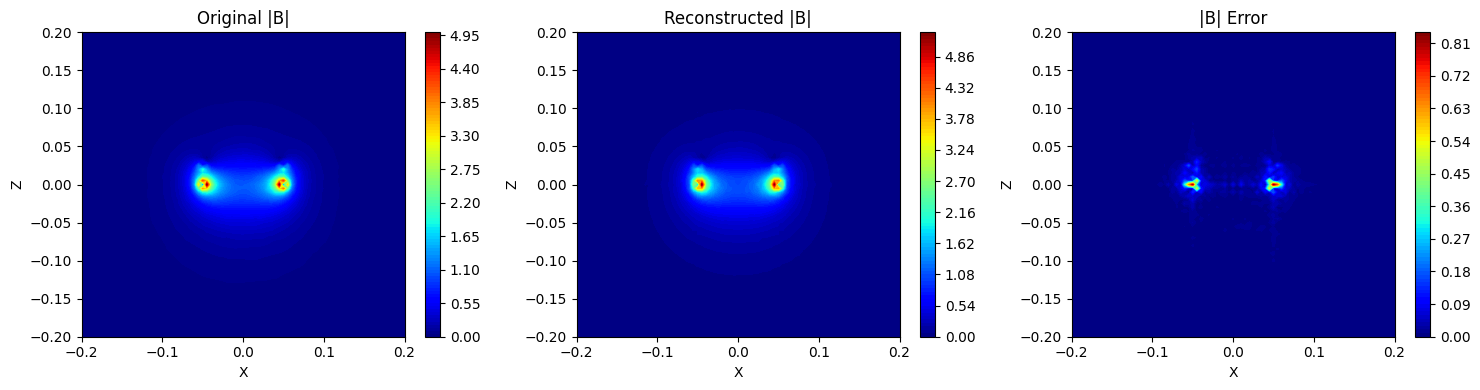

In [26]:
if __name__ == "__main__":
    filename = "B_l0_h25_200.txt"
    b_scale = 10000

    # Load ANSYS field
    x, y, z, Bx, By, Bz, Bmag = load_ansys_bfield(filename)

    # Scale B by 1000
    Bx *= b_scale
    By *= b_scale
    Bz *= b_scale
    Bmag = np.sqrt(Bx**2 + By**2 + Bz**2)

    # Reshape to regular grid
    xs, ys, zs, Bxg, Byg, Bzg = reshape_to_grid(x, y, z, Bx, By, Bz)
    Bmag_g = np.sqrt(Bxg**2 + Byg**2 + Bzg**2)

    dx = xs[1] - xs[0]
    dy = ys[1] - ys[0]
    dz = zs[1] - zs[0]

    # Pad before FFT to reduce wraparound artifacts
    pad = ((16, 16), (16, 16), (16, 16))
    Bx_pad, By_pad, Bz_pad = pad_field(Bxg, Byg, Bzg, pad=pad, mode="edge")

    # Project to divergence-free field first
    Bx_proj_pad, By_proj_pad, Bz_proj_pad = project_B_to_div_free_fft(
        Bx_pad, By_pad, Bz_pad, dx, dy, dz
    )

    # Reconstruct A from projected B using FFT
    Ax_pad, Ay_pad, Az_pad = solve_A_from_B_fft(
        Bx_proj_pad, By_proj_pad, Bz_proj_pad, dx, dy, dz
    )

    # Reconstruct B from A using spectral curl
    Bx_ref_pad, By_ref_pad, Bz_ref_pad, _ = curl_of_A_fft(
        Ax_pad, Ay_pad, Az_pad, dx, dy, dz
    )

    # Crop back to original domain
    Bx_proj = crop_field(Bx_proj_pad, pad)
    By_proj = crop_field(By_proj_pad, pad)
    Bz_proj = crop_field(Bz_proj_pad, pad)
    Bmag_proj = np.sqrt(Bx_proj**2 + By_proj**2 + Bz_proj**2)

    Bx_ref = crop_field(Bx_ref_pad, pad)
    By_ref = crop_field(By_ref_pad, pad)
    Bz_ref = crop_field(Bz_ref_pad, pad)
    Bmag_ref = np.sqrt(Bx_ref**2 + By_ref**2 + Bz_ref**2)

    # Plots to keep
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    c1 = plot_grid_slice_contour(xs, ys, zs, Bmag_g, ax=axes[0], title="Original |B|")
    c2 = plot_grid_slice_contour(xs, ys, zs, Bmag_ref, ax=axes[1], title="Reconstructed |B|")
    c3 = plot_grid_slice_contour(xs, ys, zs, np.abs(Bmag_ref - Bmag_g), ax=axes[2], title="|B| Error")

    fig.colorbar(c1, ax=axes[0])
    fig.colorbar(c2, ax=axes[1])
    fig.colorbar(c3, ax=axes[2])

    plt.tight_layout()
    plt.show()

## F: Cartesian–Cylindrical Conversion
These functions convert the vector potential **between Cartesian and cylindrical coordinate representations** on the same grid.

- `cartesian_A_to_cylindrical(xs, ys, zs, Ax, Ay, Az)`  
  Converts Cartesian components `(Ax, Ay, Az)` into cylindrical components `(Arho, Atheta, Az)` using the local radial and azimuthal directions.

- `cylindrical_A_to_cartesian(xs, ys, zs, Arho, Atheta, Az)`  
  Converts cylindrical components back to Cartesian `(Ax, Ay, Az)`.

**Input**
- `xs, ys, zs` – Grid coordinate arrays  
- `Ax, Ay, Az` or `Arho, Atheta, Az` – Vector potential components

**Output**
- Converted vector potential components on the same 3D grid.

which allow the vector potential to be analyzed in **cylindrical symmetry**, useful for Fourier expansions in the angular direction.

In [27]:

from scipy.interpolate import RegularGridInterpolator

# =========================================================
# 8) Cylindrical coordinate conversion for vector potential
# =========================================================
def cartesian_A_to_cylindrical(xs, ys, zs, Ax, Ay, Az):
    """
    Convert vector potential components from Cartesian (Ax, Ay, Az)
    to cylindrical-like components (Arho, Atheta, Az) on the same grid.

    Returns
    -------
    rho : 3D array
        Radial coordinate at each grid point
    theta : 3D array
        Azimuthal angle at each grid point
    Z : 3D array
        Z coordinate mesh
    Arho : 3D array
        Radial component of A
    Atheta : 3D array
        Azimuthal component of A
    Az : 3D array
        Axial component of A (unchanged)
    """
    X, Y, Z = np.meshgrid(xs, ys, zs, indexing="ij")

    rho = np.sqrt(X**2 + Y**2)
    theta = np.arctan2(Y, X)

    cos_t = np.cos(theta)
    sin_t = np.sin(theta)

    Arho = Ax * cos_t + Ay * sin_t
    Atheta = -Ax * sin_t + Ay * cos_t

    return rho, theta, Z, Arho, Atheta, Az


def cylindrical_A_to_cartesian(xs, ys, zs, Arho, Atheta, Az):
    """
    Convert vector potential components from cylindrical
    (Arho, Atheta, Az) back to Cartesian (Ax, Ay, Az).

    Returns
    -------
    Ax, Ay, Az : 3D arrays
        Cartesian components of the vector potential
    """
    X, Y, Z = np.meshgrid(xs, ys, zs, indexing="ij")

    theta = np.arctan2(Y, X)
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)

    Ax = Arho * cos_t - Atheta * sin_t
    Ay = Arho * sin_t + Atheta * cos_t

    return Ax, Ay, Az

## F: Cylindrical Fourier Fitting

This section builds a **true cylindrical representation** of the field and uses a **Fourier series in the angular coordinate** to compress and reconstruct it.

**Workflow**

Cartesian grid field  
→ build a cylindrical sampling grid $(\rho,\theta,z)$  
→ interpolate the field from Cartesian to cylindrical coordinates  
→ fit Fourier coefficients in $(\theta)$ for each $(\rho,z)$ location  
→ store the coefficients in arrays of shape `(nrho, nz, 2*N+1)`  
→ evaluate the coefficients to reconstruct the full field on `(nrho, ntheta, nz)`

**Main functions**

- `build_fourier_matrix(theta_vals, N)`  
  Builds the Fourier basis matrix up to order `N`.

- `fit_fourier_coefficients(theta_vals, f_vals, N)`  
  Fits Fourier coefficients for one angular profile.

- `evaluate_fourier_coefficients(theta_vals, coeffs, N)`  
  Evaluates the fitted Fourier series at selected angles.

- `make_cylindrical_grid_from_cartesian(xs, ys, zs, ntheta=128, ...)`  
  Creates a true cylindrical grid from the Cartesian target grid.

- `interpolate_field_to_cylindrical_grid(xs, ys, zs, F, rho_vals, theta_vals, z_vals, ...)`  
  Interpolates a Cartesian field onto the cylindrical grid.

- `fit_fourier_coefficients_3d(F_rtz, theta_vals, N)`  
  Fits Fourier coefficients for a full field on the cylindrical grid, returning coefficients with shape `(nrho, nz, 2*N+1)`.

- `evaluate_fourier_coefficients_3d(coeffs_rzN, theta_vals, N)`  
  Reconstructs the full field on `(nrho, ntheta, nz)` from the stored coefficients.

- `fit_vector_fourier_coefficients_on_cyl_grid(...)`  
  Applies the Fourier fit to the three cylindrical vector components separately.

- `evaluate_vector_fourier_coefficients_on_cyl_grid(...)`  
  Reconstructs the three cylindrical vector components from their Fourier coefficients.

The Fourier expansion used is

\[
f(\theta) \approx a_0 + \sum_{n=1}^{N}\left[a_n\cos(n\theta) + b_n\sin(n\theta)\right]
\]

so the field is represented by angular Fourier modes at each radius and axial position.

In [ ]:
from scipy.interpolate import RegularGridInterpolator
import numpy as np


# =========================================================
# 9) Fourier basis helpers
# =========================================================
def build_fourier_matrix(theta_vals, N):
    """
    Build the Fourier design matrix for angles theta_vals up to order N.

    Basis ordering:
        [1, cos(theta), sin(theta), cos(2theta), sin(2theta), ..., cos(Ntheta), sin(Ntheta)]

    Parameters
    ----------
    theta_vals : array_like, shape (ntheta,)
        Angular sample locations in radians.
    N : int
        Maximum Fourier order.

    Returns
    -------
    A : ndarray, shape (ntheta, 2*N + 1)
        Fourier design matrix.
    """
    theta_vals = np.asarray(theta_vals, dtype=float)
    M = len(theta_vals)

    cols = [np.ones(M)]
    for n in range(1, N + 1):
        cols.append(np.cos(n * theta_vals))
        cols.append(np.sin(n * theta_vals))

    return np.column_stack(cols)


def fit_fourier_coefficients(theta_vals, f_vals, N):
    """
    Fit Fourier coefficients for one 1D function f(theta).

    Parameters
    ----------
    theta_vals : array_like, shape (ntheta,)
        Angular sample locations.
    f_vals : array_like, shape (ntheta,)
        Function values sampled at theta_vals.
    N : int
        Maximum Fourier order.

    Returns
    -------
    coeffs : ndarray, shape (2*N + 1,)
        Fitted Fourier coefficients.
    """
    theta_vals = np.asarray(theta_vals, dtype=float)
    f_vals = np.asarray(f_vals, dtype=float)

    if theta_vals.ndim != 1 or f_vals.ndim != 1:
        raise ValueError("theta_vals and f_vals must be 1D arrays")
    if len(theta_vals) == 0:
        raise ValueError("Empty theta_vals")
    if len(theta_vals) != len(f_vals):
        raise ValueError("theta_vals and f_vals must have the same length")

    A = build_fourier_matrix(theta_vals, N)
    coeffs, *_ = np.linalg.lstsq(A, f_vals, rcond=None)
    return coeffs


def evaluate_fourier_coefficients(theta_vals, coeffs, N):
    """
    Evaluate a Fourier series at given angles.

    Parameters
    ----------
    theta_vals : array_like, shape (ntheta,)
        Angular positions where the series is evaluated.
    coeffs : array_like, shape (2*N + 1,)
        Fourier coefficients.
    N : int
        Maximum Fourier order.

    Returns
    -------
    f_eval : ndarray, shape (ntheta,)
        Evaluated series values.
    """
    theta_vals = np.asarray(theta_vals, dtype=float)
    coeffs = np.asarray(coeffs, dtype=float)

    A = build_fourier_matrix(theta_vals, N)
    return A @ coeffs


# =========================================================
# 10) Build a true cylindrical sampling grid
# =========================================================
def make_cylindrical_grid_from_cartesian(xs, ys, zs, ntheta=128, decimals=12):
    """
    Construct a cylindrical grid from the Cartesian target grid.

    The returned rho values are the unique radii present in the Cartesian grid.
    Theta is sampled uniformly on [−pi, pi).

    Parameters
    ----------
    xs, ys, zs : 1D arrays
        Cartesian grid coordinates.
    ntheta : int
        Number of uniform angular samples.
    decimals : int
        Rounding precision used when extracting unique rho values.

    Returns
    -------
    rho_vals : ndarray, shape (nrho,)
        Unique radii present in the Cartesian grid.
    theta_vals : ndarray, shape (ntheta,)
        Uniform angular sample points.
    z_vals : ndarray, shape (nz,)
        Copy of zs.
    """
    X, Y, _ = np.meshgrid(xs, ys, zs, indexing="ij")
    rho_grid = np.sqrt(X[:, :, 0] ** 2 + Y[:, :, 0] ** 2)

    rho_vals = np.unique(np.round(rho_grid.ravel(), decimals=decimals))
    theta_vals = np.linspace(-np.pi, np.pi, ntheta, endpoint=False)
    z_vals = np.asarray(zs, dtype=float)

    return rho_vals, theta_vals, z_vals


# =========================================================
# 11) Interpolate a Cartesian field onto a true cylindrical grid
# =========================================================
def interpolate_field_to_cylindrical_grid(
    xs,
    ys,
    zs,
    F,
    rho_vals,
    theta_vals,
    z_vals,
    fill_value=0.0,
):
    """
    Interpolate a scalar field F(x,y,z) from a Cartesian grid onto
    a cylindrical grid F(rho, theta, z).

    Parameters
    ----------
    xs, ys, zs : 1D arrays
        Cartesian grid coordinates.
    F : ndarray, shape (nx, ny, nz)
        Scalar field on the Cartesian grid.
    rho_vals : ndarray, shape (nrho,)
        Cylindrical radial coordinates.
    theta_vals : ndarray, shape (ntheta,)
        Cylindrical angular coordinates.
    z_vals : ndarray, shape (nz,)
        Cylindrical axial coordinates.
    fill_value : float
        Value used outside interpolation bounds.

    Returns
    -------
    F_cyl : ndarray, shape (nrho, ntheta, nz)
        Field sampled on the cylindrical grid.
    """
    interp = RegularGridInterpolator(
        (xs, ys, zs),
        F,
        bounds_error=False,
        fill_value=fill_value,
    )

    R, T, Z = np.meshgrid(rho_vals, theta_vals, z_vals, indexing="ij")
    X = R * np.cos(T)
    Y = R * np.sin(T)

    pts = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
    F_cyl = interp(pts).reshape(len(rho_vals), len(theta_vals), len(z_vals))

    return F_cyl


# =========================================================
# 12) Fit Fourier coefficients on a cylindrical grid
# =========================================================
def fit_fourier_coefficients_3d(F_rtz, theta_vals, N):
    """
    Fit Fourier coefficients for a field sampled on a cylindrical grid.

    Parameters
    ----------
    F_rtz : ndarray, shape (nrho, ntheta, nz)
        Field values on the cylindrical grid.
    theta_vals : ndarray, shape (ntheta,)
        Angular sample locations.
    N : int
        Maximum Fourier order.

    Returns
    -------
    coeffs : ndarray, shape (nrho, nz, 2*N + 1)
        Fourier coefficients for each (rho, z).
        The last axis stores:
        [a0, a1, b1, a2, b2, ..., aN, bN]
    """
    F_rtz = np.asarray(F_rtz, dtype=float)

    if F_rtz.ndim != 3:
        raise ValueError("F_rtz must have shape (nrho, ntheta, nz)")

    nrho, ntheta, nz = F_rtz.shape
    if len(theta_vals) != ntheta:
        raise ValueError("theta_vals length must match F_rtz.shape[1]")

    A = build_fourier_matrix(theta_vals, N)   # (ntheta, 2N+1)
    ncoeff = 2 * N + 1

    coeffs = np.empty((nrho, nz, ncoeff), dtype=float)

    for i in range(nrho):
        for k in range(nz):
            f = F_rtz[i, :, k]
            c, *_ = np.linalg.lstsq(A, f, rcond=None)
            coeffs[i, k, :] = c

    return coeffs


# =========================================================
# 13) Evaluate Fourier coefficients to reconstruct full field
# =========================================================
def evaluate_fourier_coefficients_3d(coeffs_rzN, theta_vals, N):
    """
    Reconstruct a full cylindrical field from Fourier coefficients.

    Parameters
    ----------
    coeffs_rzN : ndarray, shape (nrho, nz, 2*N + 1)
        Fourier coefficients for each (rho, z).
    theta_vals : ndarray, shape (ntheta,)
        Angular evaluation points.
    N : int
        Maximum Fourier order.

    Returns
    -------
    F_rtz : ndarray, shape (nrho, ntheta, nz)
        Reconstructed field on the cylindrical grid.
    """
    coeffs_rzN = np.asarray(coeffs_rzN, dtype=float)

    if coeffs_rzN.ndim != 3:
        raise ValueError("coeffs_rzN must have shape (nrho, nz, 2*N + 1)")

    nrho, nz, ncoeff = coeffs_rzN.shape
    expected = 2 * N + 1
    if ncoeff != expected:
        raise ValueError(f"Expected last dimension {expected}, got {ncoeff}")

    A = build_fourier_matrix(theta_vals, N)   # (ntheta, 2N+1)

    F_rtz = np.empty((nrho, len(theta_vals), nz), dtype=float)

    for i in range(nrho):
        for k in range(nz):
            F_rtz[i, :, k] = A @ coeffs_rzN[i, k, :]

    return F_rtz


# =========================================================
# 14) Fit vector field coefficients on cylindrical grid
# =========================================================
def fit_vector_fourier_coefficients_on_cyl_grid(
    Arho_rtz,
    Atheta_rtz,
    Az_rtz,
    theta_vals,
    N,
):
    """
    Fit Fourier coefficients for the three cylindrical vector potential components.

    Parameters
    ----------
    Arho_rtz, Atheta_rtz, Az_rtz : ndarray, shape (nrho, ntheta, nz)
        Vector potential components on a cylindrical grid.
    theta_vals : ndarray
        Angular sample locations.
    N : int
        Maximum Fourier order.

    Returns
    -------
    Cr, Ct, Cz : ndarrays, shape (nrho, nz, 2*N + 1)
        Fourier coefficients for Arho, Atheta, Az.
    """
    Cr = fit_fourier_coefficients_3d(Arho_rtz, theta_vals, N)
    Ct = fit_fourier_coefficients_3d(Atheta_rtz, theta_vals, N)
    Cz = fit_fourier_coefficients_3d(Az_rtz, theta_vals, N)
    return Cr, Ct, Cz


def evaluate_vector_fourier_coefficients_on_cyl_grid(Cr, Ct, Cz, theta_vals, N):
    """
    Reconstruct the three cylindrical vector potential components from
    their Fourier coefficients.

    Parameters
    ----------
    Cr, Ct, Cz : ndarrays, shape (nrho, nz, 2*N + 1)
        Fourier coefficients for Arho, Atheta, Az.
    theta_vals : ndarray
        Angular evaluation points.
    N : int
        Maximum Fourier order.

    Returns
    -------
    Arho_rtz, Atheta_rtz, Az_rtz : ndarrays, shape (nrho, ntheta, nz)
        Reconstructed cylindrical vector potential components.
    """
    Arho_rtz = evaluate_fourier_coefficients_3d(Cr, theta_vals, N)
    Atheta_rtz = evaluate_fourier_coefficients_3d(Ct, theta_vals, N)
    Az_rtz = evaluate_fourier_coefficients_3d(Cz, theta_vals, N)
    return Arho_rtz, Atheta_rtz, Az_rtz

## F: Plot Mid-Plane Magnetic Field

These functions generate contour plots of the magnetic field on the **mid-plane (Y midpoint)** of the grid.

- `plot_B_comparison(...)`  
  Plots a selected magnetic field component (`Bx`, `By`, or `Bz`) for the reference field and reconstructed fields.

- `plot_Bmag_comparison(...)`  
  Plots the magnetic field magnitude \(|B|\) for the reference field and reconstructed fields.

The plots are shown side-by-side to compare how different Fourier truncation orders reproduce the field.

In [30]:

# =========================================================
# 11) Plot B component comparison on mid-plane
# =========================================================
def plot_B_comparison(xs, ys, zs, Bref, Blist, orders, component="Bz"):
    comp_idx = {"Bx": 0, "By": 1, "Bz": 2}[component]

    j = len(ys) // 2
    X2, Z2 = np.meshgrid(xs, zs, indexing="ij")

    ncols = len(orders) + 1
    fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4), constrained_layout=True)

    ref = Bref[comp_idx][:, j, :]
    im0 = axes[0].contourf(X2, Z2, ref, levels=40)
    axes[0].set_title(f"Reference {component}")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("z")
    fig.colorbar(im0, ax=axes[0])

    for ax, Bn, N in zip(axes[1:], Blist, orders):
        field = Bn[comp_idx][:, j, :]
        im = ax.contourf(X2, Z2, field, levels=40)
        ax.set_title(f"{component} from N={N}")
        ax.set_xlabel("x")
        ax.set_ylabel("z")
        fig.colorbar(im, ax=ax)

    plt.show()


# =========================================================
# 12) Plot |B| comparison on mid-plane
# =========================================================
def plot_Bmag_comparison(xs, ys, zs, Bref, Blist, orders):
    Bx0, By0, Bz0 = Bref
    Bmag0 = np.sqrt(Bx0**2 + By0**2 + Bz0**2)

    j = len(ys) // 2
    X2, Z2 = np.meshgrid(xs, zs, indexing="ij")

    ncols = len(orders) + 1
    fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4), constrained_layout=True)

    ref = Bmag0[:, j, :]
    im0 = axes[0].contourf(X2, Z2, ref, levels=40)
    axes[0].set_title("Reference |B|")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("z")
    fig.colorbar(im0, ax=axes[0])

    for ax, Bn, N in zip(axes[1:], Blist, orders):
        Bx, By, Bz = Bn
        Bmag = np.sqrt(Bx**2 + By**2 + Bz**2)
        field = Bmag[:, j, :]
        im = ax.contourf(X2, Z2, field, levels=40)
        ax.set_title(f"|B| from N={N}")
        ax.set_xlabel("x")
        ax.set_ylabel("z")
        fig.colorbar(im, ax=ax)

    plt.show()

# M: Rebuild Cylindrical FFT (A, B)

This workflow processes magnetic field data exported from ANSYS, reconstructs the vector potential, and analyzes the field using a cylindrical Fourier representation.

**Pipeline**

ANSYS magnetic field file  
→ load and scale the magnetic field  
→ reshape scattered data onto a regular Cartesian grid  
→ pad the grid and project the field to a divergence-free form using FFT  
→ compute the vector potential **A** from the projected magnetic field  
→ reconstruct a reference magnetic field from **curl(A)**  
→ convert the vector potential from Cartesian to cylindrical components  
→ interpolate the cylindrical field onto a true cylindrical grid \((\rho,\theta,z)\)  
→ fit angular Fourier coefficients for each \((\rho,z)\) location  
→ reconstruct truncated vector potentials for selected Fourier orders  
→ convert reconstructed cylindrical fields back to Cartesian coordinates  
→ compute reconstructed magnetic fields using **curl(A)**  
→ compare reconstructed fields with the reference field using contour plots

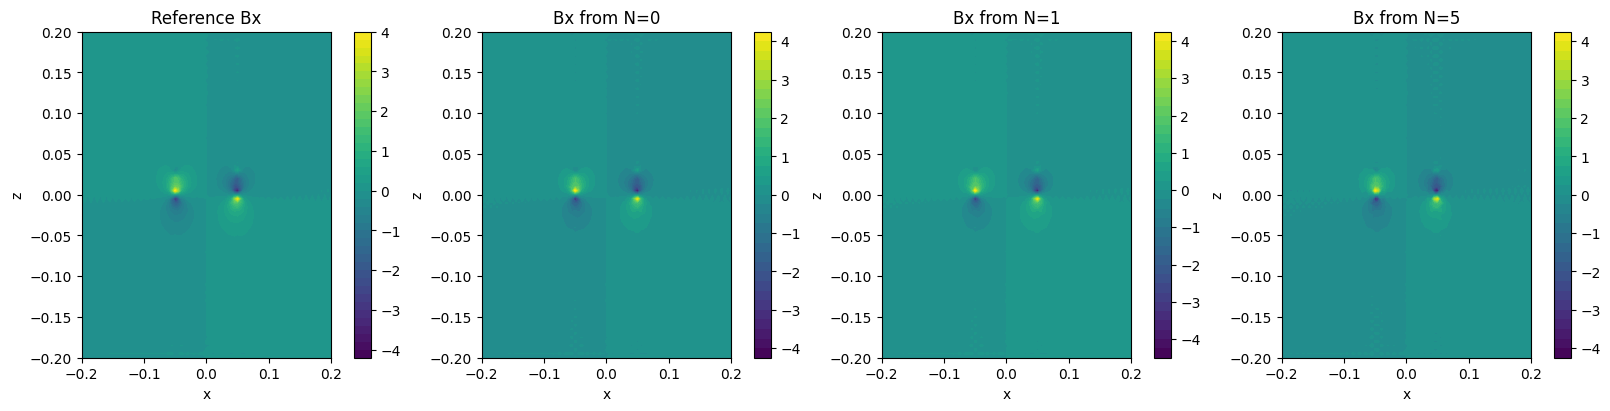

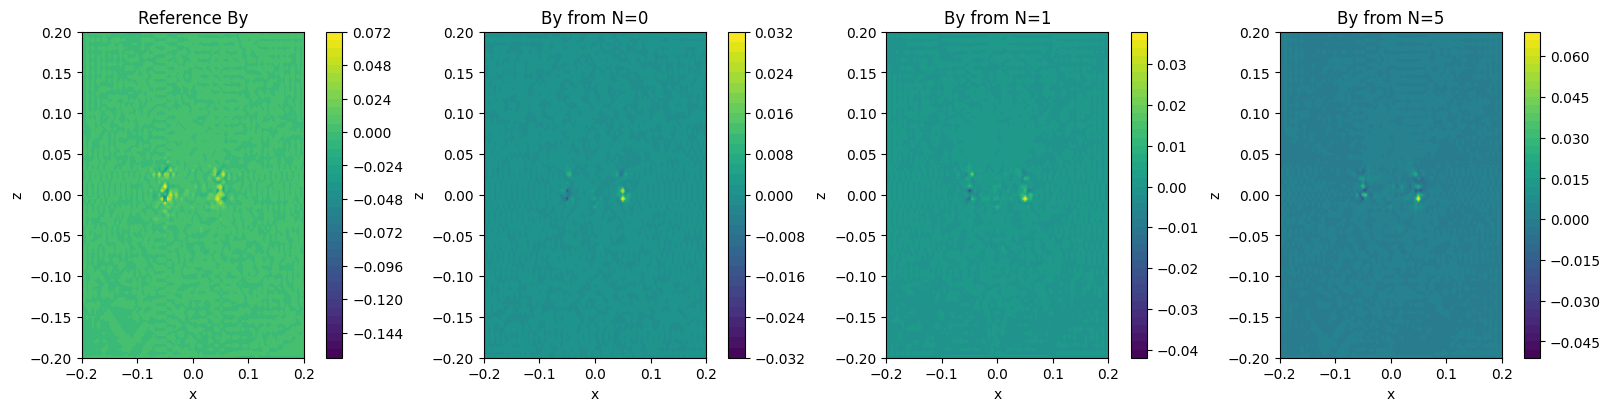

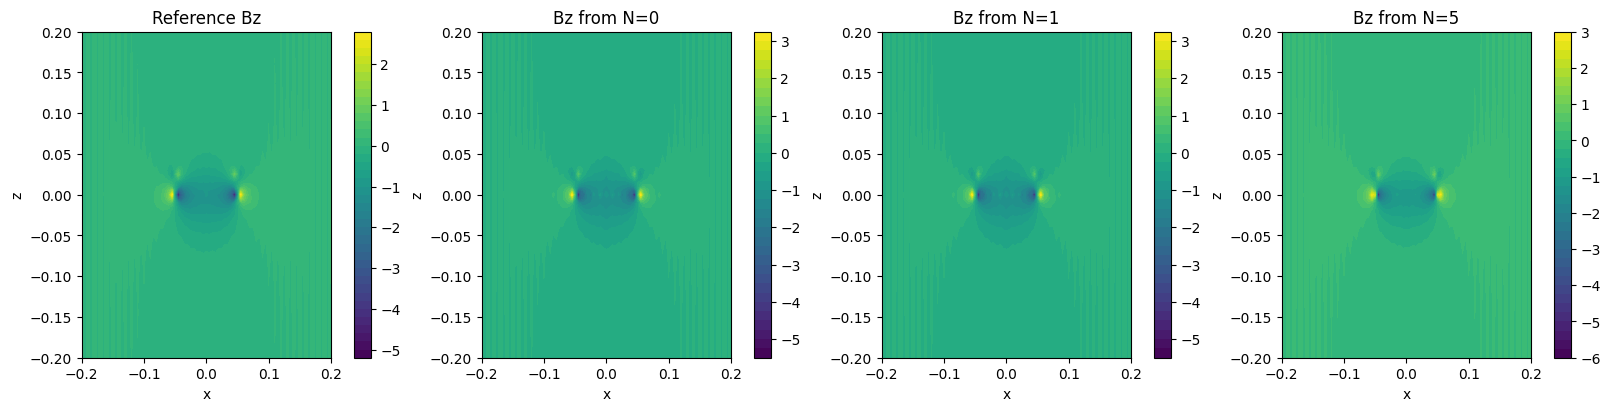

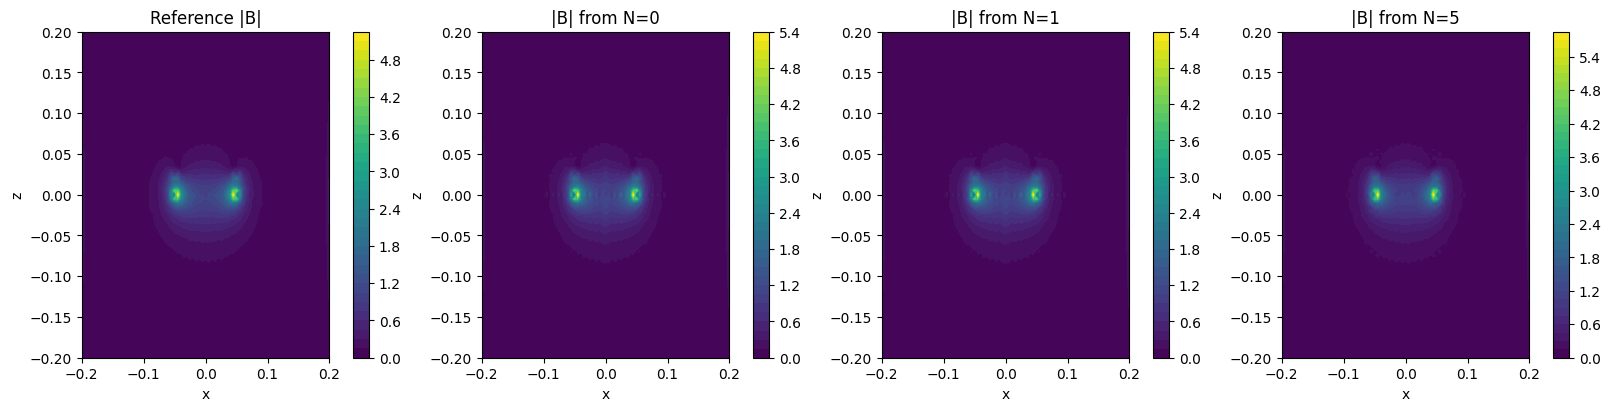

In [ ]:

if __name__ == "__main__":
    filename = "B_l0_h25_200.txt"
    b_scale = 10000.0

    # Load ANSYS field
    x, y, z, Bx, By, Bz, Bmag = load_ansys_bfield(filename)

    # Scale B
    Bx *= b_scale
    By *= b_scale
    Bz *= b_scale
    Bmag = np.sqrt(Bx**2 + By**2 + Bz**2)

    # Reshape scattered data to a regular Cartesian grid
    xs, ys, zs, Bxg, Byg, Bzg = reshape_to_grid(x, y, z, Bx, By, Bz)
    Bmag_g = np.sqrt(Bxg**2 + Byg**2 + Bzg**2)

    dx = xs[1] - xs[0]
    dy = ys[1] - ys[0]
    dz = zs[1] - zs[0]

    # Pad before FFT to reduce wraparound artifacts
    pad = ((16, 16), (16, 16), (16, 16))
    Bx_pad, By_pad, Bz_pad = pad_field(Bxg, Byg, Bzg, pad=pad, mode="edge")

    # Project B to a divergence-free field
    Bx_proj_pad, By_proj_pad, Bz_proj_pad = project_B_to_div_free_fft(
        Bx_pad, By_pad, Bz_pad, dx, dy, dz
    )

    # Solve for vector potential A from projected B
    Ax_pad, Ay_pad, Az_pad = solve_A_from_B_fft(
        Bx_proj_pad, By_proj_pad, Bz_proj_pad, dx, dy, dz
    )

    # Crop fields back to the original domain
    Ax = crop_field(Ax_pad, pad)
    Ay = crop_field(Ay_pad, pad)
    Az = crop_field(Az_pad, pad)

    Bx_proj = crop_field(Bx_proj_pad, pad)
    By_proj = crop_field(By_proj_pad, pad)
    Bz_proj = crop_field(Bz_proj_pad, pad)
    Bmag_proj = np.sqrt(Bx_proj**2 + By_proj**2 + Bz_proj**2)

    # Reference magnetic field reconstructed from A
    Bx_ref, By_ref, Bz_ref, Bmag_ref = curl_of_A_fft(Ax, Ay, Az, dx, dy, dz)

    # Convert A from Cartesian to cylindrical components on the Cartesian grid
    rho, theta, Z, Arho, Atheta, Az_cyl = cartesian_A_to_cylindrical(
        xs, ys, zs, Ax, Ay, Az
    )

    # Build a true cylindrical sampling grid
    ntheta = 128
    rho_vals, theta_vals, z_vals = make_cylindrical_grid_from_cartesian(
        xs, ys, zs, ntheta=ntheta
    )

    # Interpolate cylindrical components onto the true cylindrical grid
    Arho_rtz = interpolate_field_to_cylindrical_grid(
        xs, ys, zs, Arho, rho_vals, theta_vals, z_vals, fill_value=0.0
    )
    Atheta_rtz = interpolate_field_to_cylindrical_grid(
        xs, ys, zs, Atheta, rho_vals, theta_vals, z_vals, fill_value=0.0
    )
    Az_rtz = interpolate_field_to_cylindrical_grid(
        xs, ys, zs, Az_cyl, rho_vals, theta_vals, z_vals, fill_value=0.0
    )

    # Compare several Fourier truncation orders
    orders = [0, 1, 5]
    B_recons = []

    for N in orders:
        # Fit Fourier coefficients for each cylindrical component
        Cr, Ct, Cz = fit_vector_fourier_coefficients_on_cyl_grid(
            Arho_rtz, Atheta_rtz, Az_rtz, theta_vals, N
        )

        # Reconstruct truncated cylindrical vector potential on (rho, theta, z)
        Arho_rec, Atheta_rec, Az_rec = evaluate_vector_fourier_coefficients_on_cyl_grid(
            Cr, Ct, Cz, theta_vals, N
        )

        # Map reconstructed cylindrical A back to the Cartesian grid angles
        X, Y, Z = np.meshgrid(xs, ys, zs, indexing="ij")
        rho_cart = np.sqrt(X**2 + Y**2)
        theta_cart = np.arctan2(Y, X)

        Ar_cart = np.zeros_like(Ax)
        At_cart = np.zeros_like(Ax)
        Az_cart = np.zeros_like(Ax)

        # For each z-plane and each radius, evaluate from the reconstructed cylindrical grid
        for k, z0 in enumerate(zs):
            rho_slice = rho_cart[:, :, k]
            theta_slice = theta_cart[:, :, k]

            for i, rv in enumerate(rho_vals):
                mask = np.isclose(rho_slice, rv, atol=1e-12)
                if not np.any(mask):
                    continue

                Ar_cart[:, :, k][mask] = np.interp(
                    theta_slice[mask], theta_vals, Arho_rec[i, :, k], period=2 * np.pi
                )
                At_cart[:, :, k][mask] = np.interp(
                    theta_slice[mask], theta_vals, Atheta_rec[i, :, k], period=2 * np.pi
                )
                Az_cart[:, :, k][mask] = np.interp(
                    theta_slice[mask], theta_vals, Az_rec[i, :, k], period=2 * np.pi
                )

        # Convert truncated cylindrical A back to Cartesian A
        Ax_N, Ay_N, Az_N = cylindrical_A_to_cartesian(
            xs, ys, zs, Ar_cart, At_cart, Az_cart
        )

        # Reconstruct B from curl(A)
        Bx_N, By_N, Bz_N, Bmag_N = curl_of_A_fft(Ax_N, Ay_N, Az_N, dx, dy, dz)
        B_recons.append((Bx_N, By_N, Bz_N))

    # Plots
    plot_B_comparison(xs, ys, zs, (Bx_ref, By_ref, Bz_ref), B_recons, orders, component="Bx")
    plot_B_comparison(xs, ys, zs, (Bx_ref, By_ref, Bz_ref), B_recons, orders, component="By")
    plot_B_comparison(xs, ys, zs, (Bx_ref, By_ref, Bz_ref), B_recons, orders, component="Bz")
    plot_Bmag_comparison(xs, ys, zs, (Bx_ref, By_ref, Bz_ref), B_recons, orders)